# Entrenamiento de Modelos

Como ya hemos explicado en la investigación, lo que nosotros haremos será entrenar diferentes modelos haciendo uso de los datos de entrenamiento. En este notebook haremos crearemos modelos que hagan uso de los datos extraídos usando Wav2Vec2 con preprocesamiento básico. De este modo, seguiremos el flujo básico de entrenamiento de modelos de ML:

1. Preprocesado de Datos. Esta parte ya fue realizada de manera previa con código python. En este caso, fue preprocesamiento básico.
2. Selección y Entrenamiento de Modelo.
    * Elegir algoritmo
    * Entrenar hiperparámetros
3. Evaluación de Resultados y Ajuste
4. Evaluación Final

# Wav2Vec2

In [3]:
import pickle
import numpy as np
import pandas as pd

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Modelos
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import PredefinedSplit

In [4]:
#Cargamos dataset de Embedding con Pickle
ruta_train = '../datos_entrenamiento/train_embeddings_wav2vec2.pkl'
ruta_test = '../datos_entrenamiento/test_embeddings_wav2vec2.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

#Vamos a ver la información de nuestros datasets.
print("Forma del Dataset de entrenamiento:",df_train.shape)
print()
print("Encontrar datos nulos ---> ",df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:",df_test.shape)
print()
print("Encontrar datos nulos ---> ",df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (56, 5)

Encontrar datos nulos --->  nombre_archivo    0
embedding         0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (15, 5)

Encontrar datos nulos --->  nombre_archivo    0
embedding         0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False


In [5]:
df_train.head()

,nombre_archivo,embedding,caja_toracica,grupo,fold
0,Asma con CPAP urgencias.m4a,"[-0.04241647, -0.010496411, -0.027730899, -0.0...",Obstructivo,Ventilación Invasiva,0
1,Nueva grabación 35.m4a,"[-0.008490454, 0.0018894918, -0.041521586, -0....",Mixto,Oxigeno Bajo Flujo,4
2,Nueva grabación 38.m4a,"[0.0086779585, 0.009864403, -0.09772242, -0.05...",Mixto,Oxigeno Bajo Flujo,0
3,Nueva grabación 51.m4a,"[0.008478131, 0.0033574288, -0.07301331, -0.04...",Mixto,Oxigeno Bajo Flujo,2
4,Nueva grabación 59.m4a,"[-0.012133765, -0.0026225713, -0.045569316, -0...",Mixto,Oxigeno Bajo Flujo,3


In [6]:
print(np.array(df_train['embedding'].iloc[0]).shape)

(768,)


Ahora, como se trata de un preprocesado básico, no hemos aplicado de manera previa ninguna forma de normalización de duración, Chunking o segmentación de datos. Esto representa un problema relevante, ya que los audios de entrada no tienen todos la misma longitud.

De normal, audios de distintas duraciones generarían secuencias de características cuya dimensión distintas. De este modo, cada dato generaría una matriz de distinto tamaño. Este comportamiento es incompatible con modelos de aprendizaje automático clásicos como SVM (Support Vector Machine) o RF (Random Forest), los cuales requieren que todas las muestras del conjunto de datos tengan exactamente la misma dimensionalidad de entrada. 

Sin embargo, Wav2Vec2 de manera interna, tal y como podemos observar en la linea de arriba, ha generado valores representados por un vector unidimensional de tamaño fijo (768 características). Con esto concluimos que no hace falta aplicar ningun tipo de aplanamiento, ya que ya se realizó de manera intrínseca. 

Este proceso ha podido conllevar una pérdida de la información secuencial en los datos, sin embargo, es algo necesario que necesitamos para seguir procesando los datos.

### Preprocesado Embedders Wav2Vec2

In [9]:
df_embeddings_train = pd.DataFrame(df_train['embedding'].tolist())
df_embeddings_test = pd.DataFrame(df_test['embedding'].tolist())

num_features = df_embeddings_train.shape[1]
nombres_columnas = [f'embedding_{i+1}' for i in range(num_features)]

df_embeddings_train.columns = nombres_columnas
df_embeddings_test.columns = nombres_columnas

df_metadatos_train = df_train[['nombre_archivo', 'caja_toracica', 'grupo', 'fold']].reset_index(drop=True)
df_metadatos_test = df_test[['nombre_archivo', 'caja_toracica', 'grupo', 'fold']].reset_index(drop=True)

#Extreamos directamente los datos aplanados
df_train_plano = pd.concat([df_metadatos_train, df_embeddings_train], axis=1)
df_test_plano = pd.concat([df_metadatos_test, df_embeddings_test], axis=1)

print("Shape Train Listo:", df_train_plano.shape)
print("Shape Test Listo:", df_test_plano.shape)

Shape Train Listo: (56, 772)
Shape Test Listo: (15, 772)


Ahora, en nuestro dataset para cada entrada 772 características asignadas, de las cuales podemos extraer las 4 primeras que hacen referencia al nombre del archivo y sus clasificaciones, además del fold al que pertenecerían, que no son necesarios para las técnicas de reducción de características que vamos a aplicar, siendo estas matrices de correlación, mapas de calor y PCA.

Hay que tener en cuenta que la reducción de características las hacemos en base del conjunto de datos de entrenamiento y luego lo aplicamos a los datos de test también.

In [11]:
#Primero intentaremos hacer una reducción agresiva de características, eliminando aquellas que tengan un nivel de correlación superior al 90%.
columnas_a_quitar = ['nombre_archivo', 'caja_toracica', 'grupo', 'fold']

X_train = df_train_plano.drop(columns=columnas_a_quitar)

corr_matrix = X_train.corr()

#Sabemos que 90% de correlación es un % con el que puede haber perdida de información, sin embargo, creemos que estamos trabajando con una cantidad excesivamente grande de características 
#para la poca cantidad de datos que manejamos
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] >= 0.90:
            to_drop.add(corr_matrix.columns[i])

print(len(to_drop))

242


In [12]:
# Filtrar dataset
df_train_reducido = df_train_plano.drop(columns=to_drop)
df_test_reducido = df_test_plano.drop(columns=to_drop)
print(f"Predictores originales: 768 | Reducidos: {len(df_train_reducido.columns) - 4}")

Predictores originales: 768 | Reducidos: 526


En este caso vamos a plantear algo distinto: de normal, intentaríamos seguir reduciendo la dimensionalidad con PCA para luego pasar al entrenamiento de modelos. Sin embargo, en este caso en el seguimos teniendo tantos predictores, con tan pocos datos, y teniendo en cuenta que PCA es un técnica no supervisada, lo que haremos será, no solo entrenar modelos con PCA, si no también provar otra opción: aplicar selección supervisada de sklearn. 

### RUTA PCA

In [15]:
df_train_reducido.head()

,nombre_archivo,caja_toracica,grupo,fold,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,...,embedding_756,embedding_757,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_764,embedding_766,embedding_767
0,Asma con CPAP urgencias.m4a,Obstructivo,Ventilación Invasiva,0,-0.042416,-0.010496,-0.027731,-0.051889,-0.038520,-0.122959,...,0.001189,-0.000226,0.026323,0.265626,-0.054580,-0.136641,0.084945,0.004196,-0.145539,0.042701
1,Nueva grabación 35.m4a,Mixto,Oxigeno Bajo Flujo,4,-0.008490,0.001889,-0.041522,-0.045828,0.002751,-0.114717,...,0.009781,0.000678,0.027720,0.225436,-0.056193,-0.111567,0.105948,0.005783,-0.163158,0.037295
2,Nueva grabación 38.m4a,Mixto,Oxigeno Bajo Flujo,0,0.008678,0.009864,-0.097722,-0.055905,0.042467,-0.105741,...,-0.012884,0.000941,0.028061,0.208478,-0.057430,-0.108300,0.079521,0.009427,-0.090795,0.022622
3,Nueva grabación 51.m4a,Mixto,Oxigeno Bajo Flujo,2,0.008478,0.003357,-0.073013,-0.049783,0.030509,-0.115451,...,-0.011442,0.001398,0.040192,0.208624,-0.057126,-0.095098,0.147744,0.007584,-0.096895,0.026878
4,Nueva grabación 59.m4a,Mixto,Oxigeno Bajo Flujo,3,-0.012134,-0.002623,-0.045569,-0.046910,0.019191,-0.109186,...,0.011921,-0.000565,0.028798,0.232186,-0.056280,-0.087469,0.108811,0.006679,-0.074415,0.036296


In [16]:
#Usamos un Scaler para aplicar PCA
scaler = StandardScaler()
subset_X = df_train_reducido.drop(columns = columnas_a_quitar)
df_train_reducido_pca = scaler.fit_transform(subset_X)

pca = PCA()
df_train_pca = pca.fit_transform(df_train_reducido_pca)

# Ver varianza explicada. Con esto lo que buscamos es quedarnos con el número de predictores que 
#representar X% de los otros predictores.
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.33633983 0.49061173 0.5818702  0.6492168  0.70115227 0.7401393
 0.7740305  0.8052633  0.82562435 0.84390634 0.86037606 0.87422574
 0.8872542  0.8991856  0.90915996 0.9184869  0.92579895 0.93233204
 0.9384452  0.94377214 0.9488724  0.9535097  0.9577952  0.9616606
 0.96491086 0.96809    0.97105175 0.97357666 0.9758962  0.97811395
 0.980072   0.9819401  0.9835966  0.9851454  0.98655766 0.98790735
 0.9891717  0.9903145  0.9913424  0.9922767  0.9931795  0.9940072
 0.9947609  0.9954824  0.9960911  0.9966824  0.9972511  0.9977141
 0.99815977 0.9985406  0.99890125 0.9992031  0.9994927  0.9997514
 0.9999999  0.9999999 ]


Con esta función lo que podemos observar es el número de componentes/variables de embedding reducido y el % de varianza que representan. Esto viene a significar el Nº de variables (ahora conocidos como componentes principales) que nos permiten explicar o representar un porcentaje de la variabilidad total de los datos.

Nosotros podemos observar un numero muy bajo de componentes con respecto a las 577 características despues de aplicar reducción debido a que PCA escoge el número máximo de componentes en base al número de entradas. Por eso tenemos unos 50 valores en el cumulative_variance. 

Ahora nos toca elegir que porcentaje representa la mayoría de las variables. Si elegimos uno muy bajo podemos perder información y si elegimos uno muy alto, puede llevar a sobreajuste, además de no cumplir nuestro objetivo, que es buscar reducir el Nº de predictores. Creemos que un balance correcto entre reducción de dimensionalidad y perder la cantidad mínima de información puede ser el 90% de variabilidad para este caso en específico. 

In [18]:
#Nos quedamos con el número de predictores que representen el 90%
n_components = np.argmax(cumulative_variance >= 0.90) + 4
print(f"Componentes necesarios para explicar el 90%: {n_components}")

Componentes necesarios para explicar el 90%: 18


In [19]:
scaler = StandardScaler()
X_train_num = df_train_reducido.drop(columns = columnas_a_quitar)
X_test_num = df_test_reducido.drop(columns = columnas_a_quitar)

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

n_componentes = 0.90  # El valor que ya determinamos antes
pca = PCA(n_components=n_componentes, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

#Con transform nos aseguramos de que no haya data leakage
X_test_pca = pca.transform(X_test_scaled)

n_componentes_finales = X_train_pca.shape[1]
print(f"El PCA ha seleccionado {n_componentes_finales} componentes principales.")

df_pca_train = pd.DataFrame(
    X_train_pca,
    columns=[f'Embedding_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_train_reducido.index
)
df_train_1 = pd.concat([df_train_reducido[columnas_a_quitar], df_pca_train], axis=1)

df_pca_test = pd.DataFrame(
    X_test_pca,
    columns=[f'Embedding_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_test_reducido.index
)
df_test_1 = pd.concat([df_test_reducido[columnas_a_quitar], df_pca_test], axis=1)

print("\nVista previa del conjunto de ENTRENAMIENTO post-pca:")
display(df_train_1.head())

El PCA ha seleccionado 15 componentes principales.

Vista previa del conjunto de ENTRENAMIENTO post-pca:


,nombre_archivo,caja_toracica,grupo,fold,Embedding_pca1,Embedding_pca2,Embedding_pca3,Embedding_pca4,Embedding_pca5,Embedding_pca6,Embedding_pca7,Embedding_pca8,Embedding_pca9,Embedding_pca10,Embedding_pca11,Embedding_pca12,Embedding_pca13,Embedding_pca14,Embedding_pca15
0,Asma con CPAP urgencias.m4a,Obstructivo,Ventilación Invasiva,0,-14.930582,-14.856114,-1.504236,9.525221,2.250087,0.815849,-2.812844,-2.344492,0.916783,-1.145579,-7.309733,-2.899648,-1.427426,-3.821351,-5.112483
1,Nueva grabación 35.m4a,Mixto,Oxigeno Bajo Flujo,4,-3.464709,-3.805862,4.646333,-0.147537,-1.316915,-1.920692,7.368203,1.317704,1.239034,3.721310,-0.041283,0.683409,1.915241,-2.435172,2.109056
2,Nueva grabación 38.m4a,Mixto,Oxigeno Bajo Flujo,0,6.590848,3.898220,7.184435,-8.444120,7.114106,-4.320372,0.799364,4.306955,3.782577,-0.508459,-0.685544,0.087782,-4.581148,2.785095,-1.406271
3,Nueva grabación 51.m4a,Mixto,Oxigeno Bajo Flujo,2,7.364766,6.833245,-3.071070,-2.392037,0.909061,0.912992,-0.274996,2.783870,8.423673,-0.344083,-0.443595,1.667152,-2.130574,3.533311,-1.013233
4,Nueva grabación 59.m4a,Mixto,Oxigeno Bajo Flujo,3,-2.081160,7.825796,0.429352,2.718717,-0.292255,3.158777,-4.186998,0.214214,2.716913,0.938079,-0.147270,0.401412,2.189567,6.194051,-1.078446


Podemos intentar hacer un breve análisis de los datos:

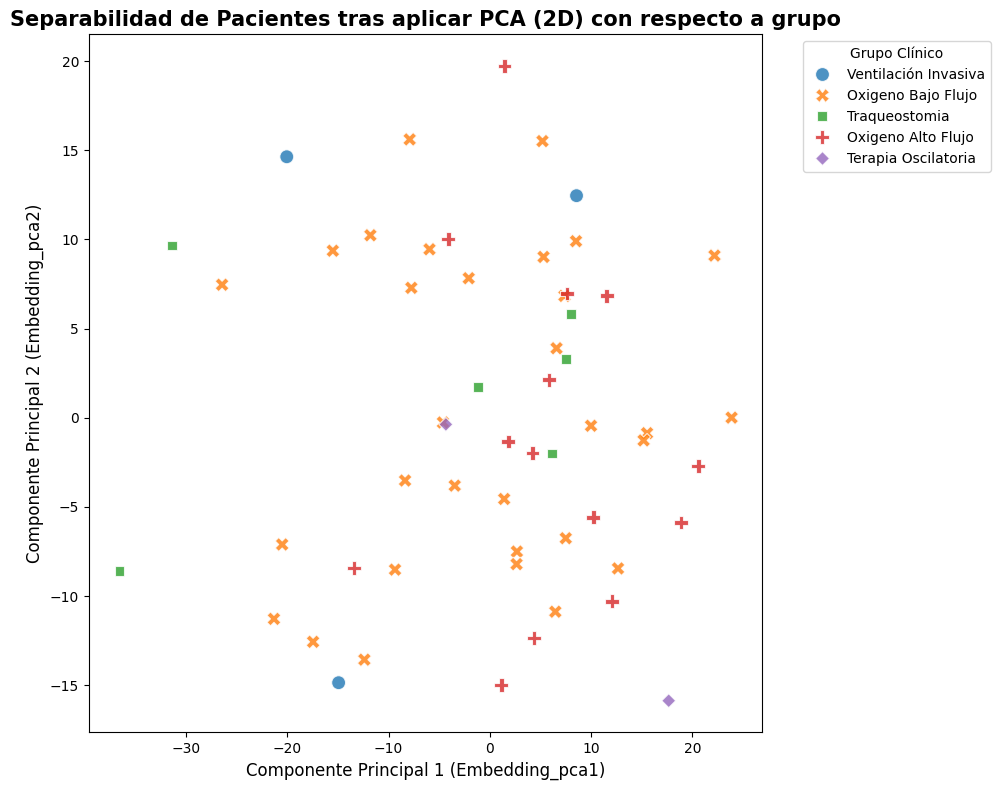

In [21]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_1, 
    x='Embedding_pca1', 
    y='Embedding_pca2', 
    hue='grupo', 
    style='grupo', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a grupo', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (Embedding_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Embedding_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupo Clínico')

plt.tight_layout()
plt.show()

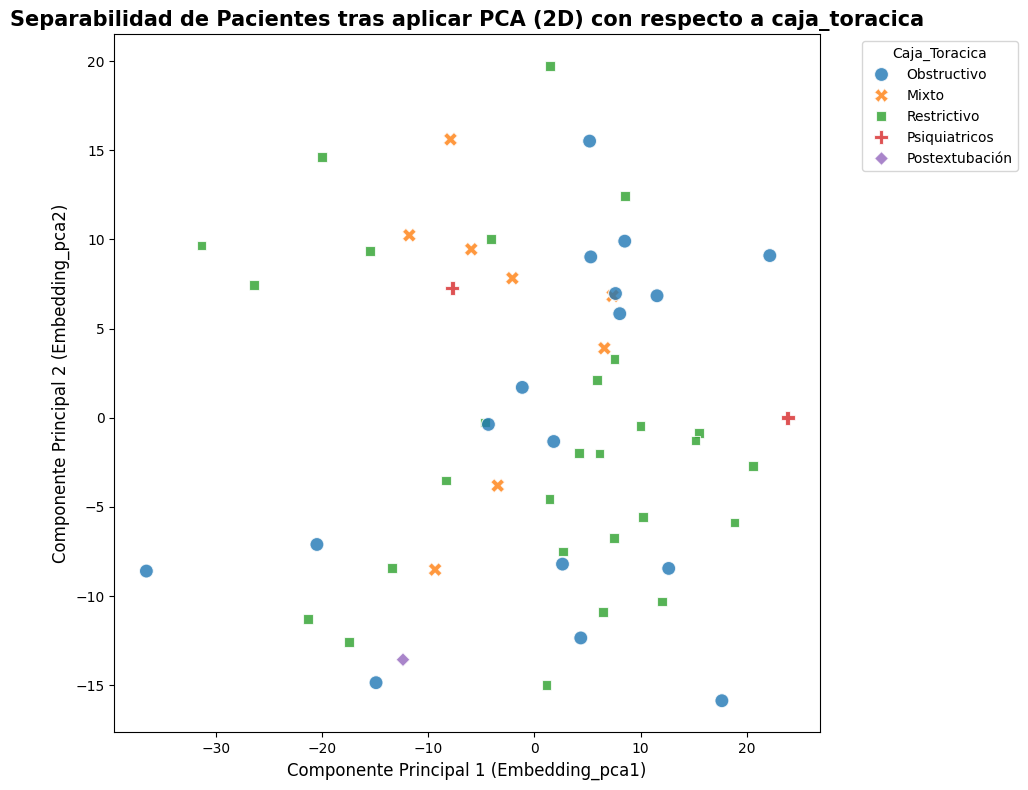

In [22]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_1, 
    x='Embedding_pca1', 
    y='Embedding_pca2', 
    hue='caja_toracica', 
    style='caja_toracica', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a caja_toracica', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (Embedding_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (Embedding_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Caja_Toracica')

plt.tight_layout()
plt.show()

Con estos gráficos de dispersión buscamos representar cada paciente como un punto en un gráfico de coordenadas, teniendo en cuenta los valores de Embedding_pca1 y Embedding_pca2. Los 2 primeros componentes principales de un PCA son aquellas que agrupan mayor cantidad de información (varianza). En ambos gráficos podemos observar que no hay nubes de puntos claramente separadas. No hay correlación verdadera entre los datos y el tipo de enfermedad con este tipo de procesamiento, se trata de una complejidad real. Necesitaremos ver que proyectan los modelos, pero de momento no creemos que se obtengan muy buenos resultados.

#### Entrenamiento Modelos con PCA

Para este caso aplicaremos modelos básicos como SVM, RF o GB sobre los datos procesados de Embedding con pca (Primera ruta). Como hemos observado, los datos de momento no presentan mucha correlación con respecto al grupo o a la caja_toracica (patología). Esperamos que para este primer análisis no obtener resultados excesivamente excelentes.

In [ ]:
def evaluar_modelo(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros para Grupo Clínico: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros para Torácica: {grid_caja.best_params_}")

    pred_grupo = grid_grupo.predict(X_test_grupo)
    pred_caja = grid_caja.predict(X_test_caja)
    
    # Evaluación GRUPOS
    acc_grupo = accuracy_score(y_test_grupo, pred_grupo)
    f1_grupo = f1_score(y_test_grupo, pred_grupo, average='macro', zero_division=0)
    print(f"GRUPOS -> Accuracy: {acc_grupo*100:.2f}% | F1-Score (Macro): {f1_grupo*100:.2f}%")
    
    # Evaluación CAJA TORÁCICA
    acc_caja = accuracy_score(y_test_caja, pred_caja)
    f1_caja = f1_score(y_test_caja, pred_caja, average='macro', zero_division=0)
    print(f"CAJA TORÁCICA -> Accuracy: {acc_caja*100:.2f}% | F1-Score (Macro): {f1_caja*100:.2f}%")
    
    # Matrices de Confusión
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold')
    
    cm_grupo = confusion_matrix(y_test_grupo, pred_grupo, labels=grid_grupo.classes_)
    sns.heatmap(cm_grupo, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=grid_grupo.classes_, yticklabels=grid_grupo.classes_)
    axes[0].set_title('Predicción: Grupo Clínico')
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)
    
    cm_caja = confusion_matrix(y_test_caja, pred_caja, labels=grid_caja.classes_)
    sns.heatmap(cm_caja, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=grid_caja.classes_, yticklabels=grid_caja.classes_)
    axes[1].set_title('Predicción: Caja Torácica')
    axes[1].set_ylabel('Etiqueta Real')
    axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [25]:
columnas_pca = [col for col in df_train_1.columns if 'pca' in col]

X_train_model = df_train_1[columnas_pca]
X_test_model = df_test_1[columnas_pca]

y_train_grupo = df_train_1['grupo']
y_test_grupo = df_test_1['grupo']

y_train_caja = df_train_1['caja_toracica']
y_test_caja = df_test_1['caja_toracica']

#Función común para la evaluación del modelo:
def evaluar_modelo(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros para Grupo Clínico: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros para Torácica: {grid_caja.best_params_}")
    
    pred_grupo = grid_grupo.predict(X_test_model)
    pred_caja = grid_caja.predict(X_test_model)
    
    acc_grupo = accuracy_score(y_test_grupo, pred_grupo)
    f1_grupo = f1_score(y_test_grupo, pred_grupo, average='macro', zero_division=0)
    print(f"GRUPOS -> Accuracy: {acc_grupo*100:.2f}% | F1-Score (Macro): {f1_grupo*100:.2f}%")
    
    acc_caja = accuracy_score(y_test_caja, pred_caja)
    f1_caja = f1_score(y_test_caja, pred_caja, average='macro', zero_division=0)
    print(f"CAJA TORÁCICA -> Accuracy: {acc_caja*100:.2f}% | F1-Score (Macro): {f1_caja*100:.2f}%")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold')
    
    cm_grupo = confusion_matrix(y_test_grupo, pred_grupo, labels=grid_grupo.classes_)
    sns.heatmap(cm_grupo, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=grid_grupo.classes_, yticklabels=grid_grupo.classes_)
    axes[0].set_title('Predicción: Grupo Clínico')
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)
    
    cm_caja = confusion_matrix(y_test_caja, pred_caja, labels=grid_caja.classes_)
    sns.heatmap(cm_caja, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=grid_caja.classes_, yticklabels=grid_caja.classes_)
    axes[1].set_title('Predicción: Caja Torácica')
    axes[1].set_ylabel('Etiqueta Real')
    axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [26]:
folds_oficiales = df_train_1['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 46.67% | F1-Score (Macro): 12.73%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 24.95%


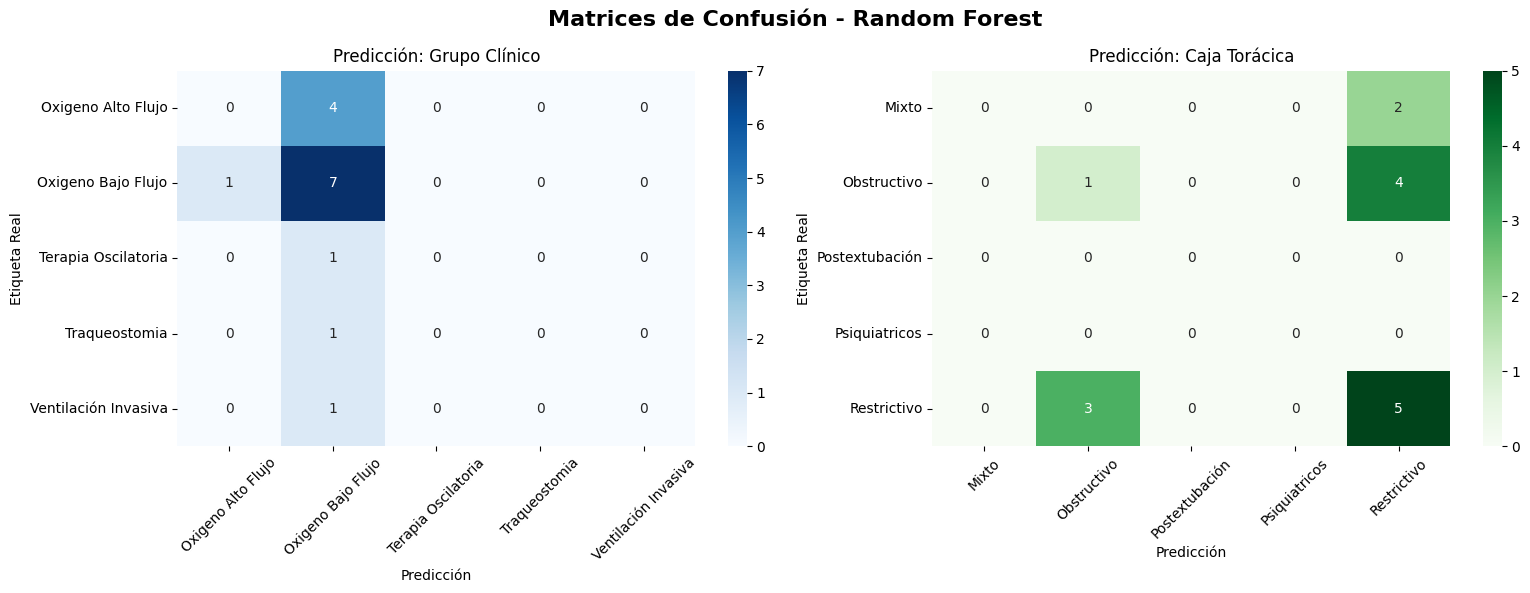

In [25]:
#Tunearemos los hiperparámetros con las ejecuciones y veremos cuales son las mejores configuraciones para cada modelo. Para cada uno haremos que la ejecución inicial sea con 
#hiperparámetros base de la documentación

#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 75}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 53.33% | F1-Score (Macro): 13.91%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 22.42%


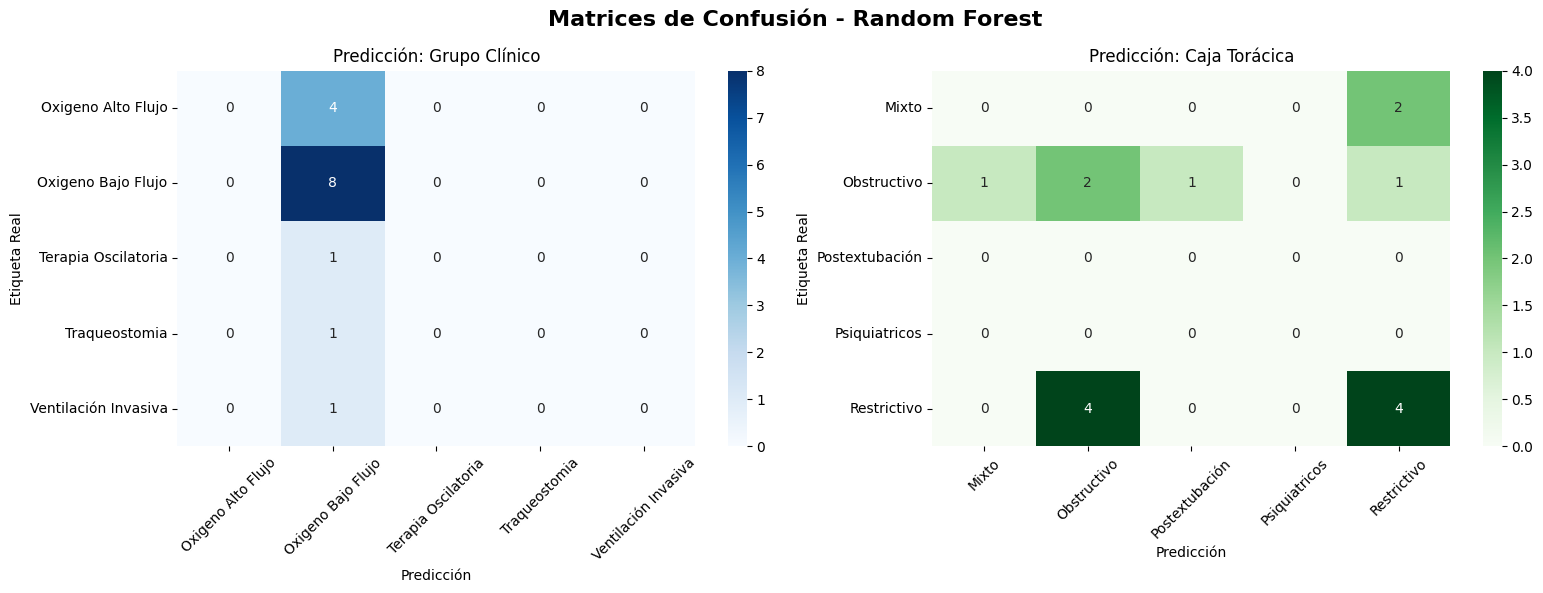

In [31]:
param_grid_rf_1 = {
    'n_estimators': [75, 100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': [1.0,'sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 53.33% | F1-Score (Macro): 13.91%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 22.42%


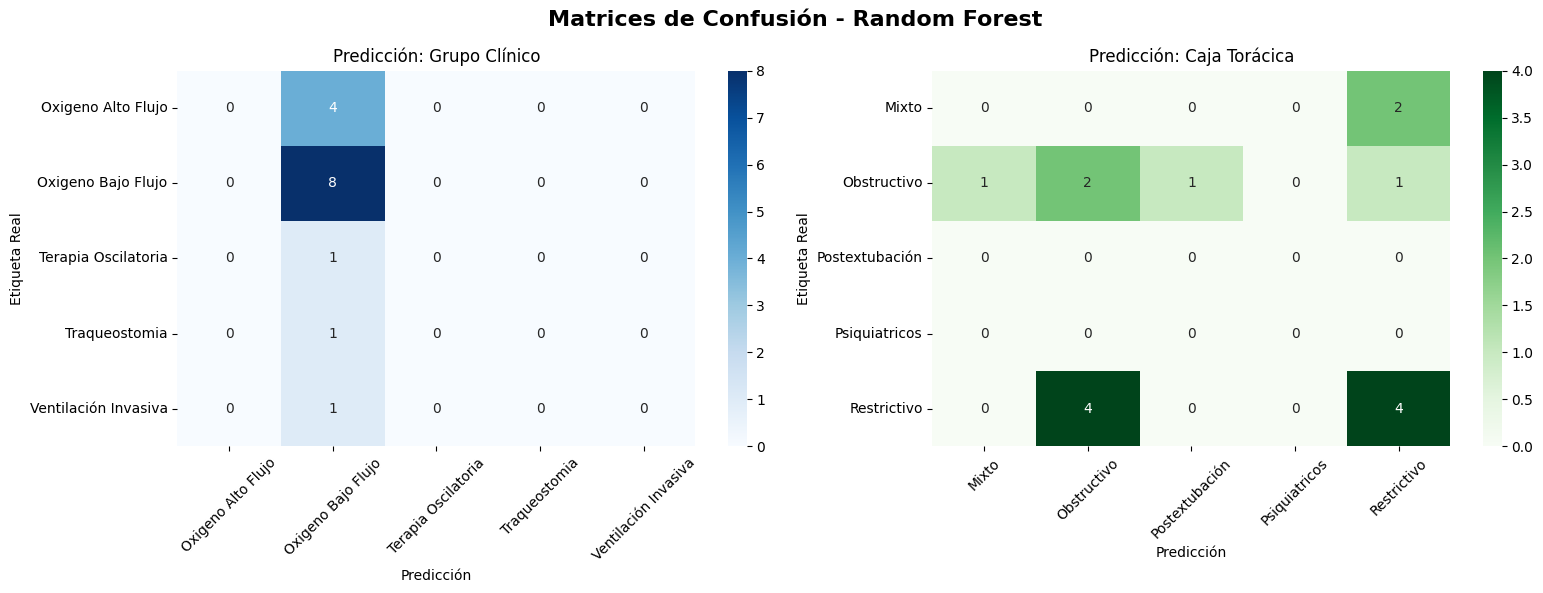

In [32]:
param_grid_rf_2_grupo = {
    'n_estimators': [50, 75],      
    'max_depth': [None],        
    'min_samples_split': [5, 7],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_2_caja = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [2, 5],    
    'max_features': [1.0, 'sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_grupo, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_caja, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 53.33% | F1-Score (Macro): 13.91%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 24.95%


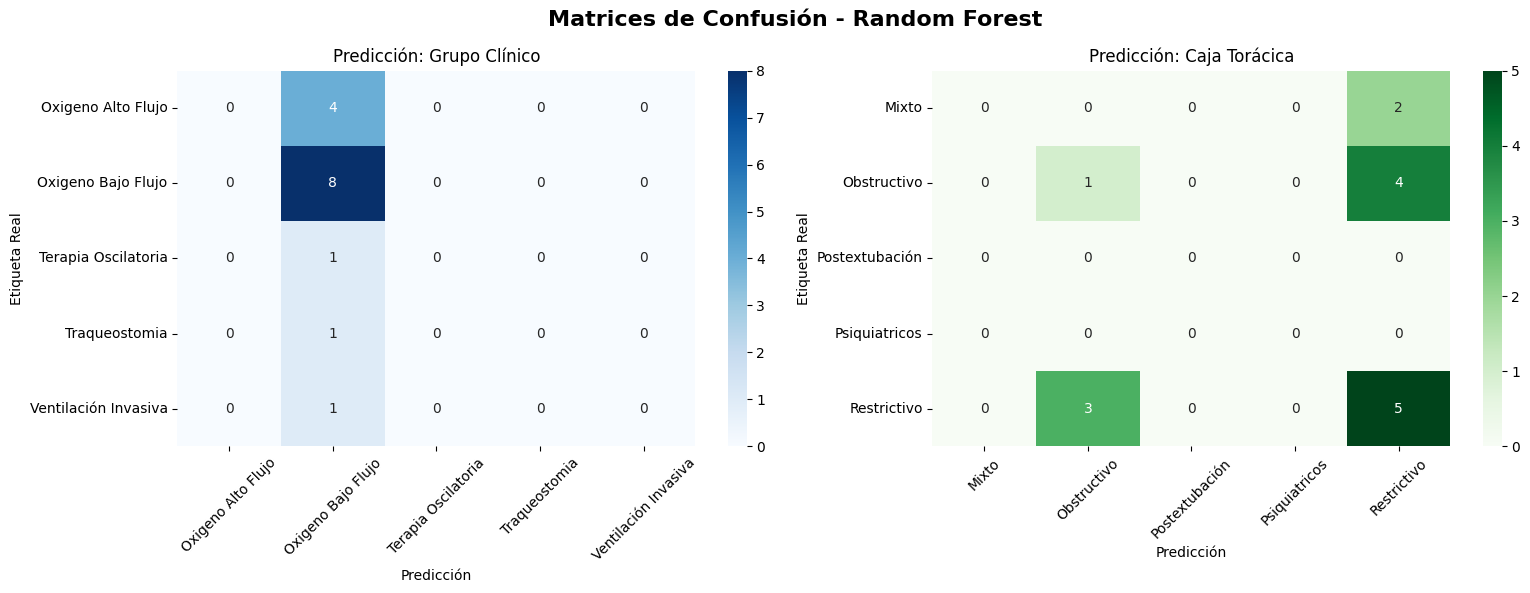

In [44]:
param_grid_rf_final_grupo = {
    'n_estimators': [50],      
    'max_depth': [None],        
    'min_samples_split': [5],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]           
}

#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_model, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")

Ya obtuvimos el mejor valor para ambos tipos de prediccón:

{'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 75}

Como podemos observar, no podemos mejorar mucho el rendimiento a través del tuneo de hiperparámetros. Se trata de un rendimiento mediocre, algo esperable para el tipo de preprocesado aplicado.

##### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 26.67% | F1-Score (Macro): 10.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 30.56%


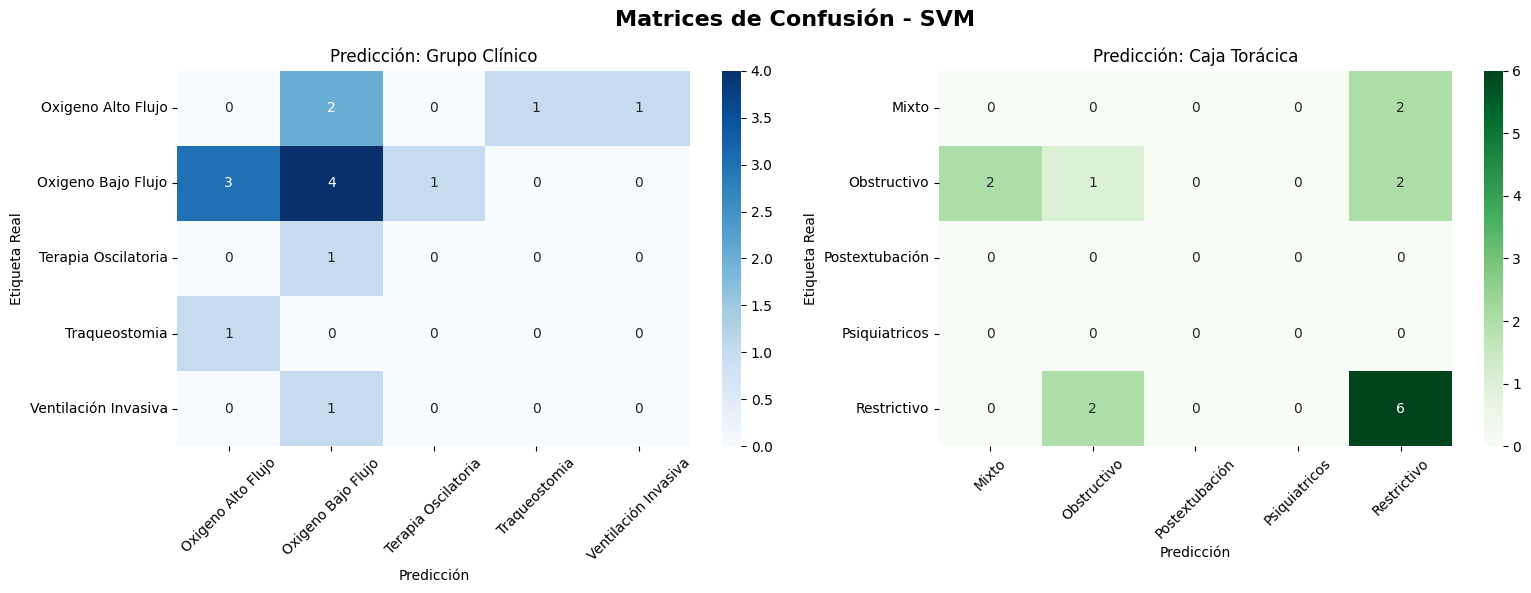

In [48]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_model, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_svm_grupo, grid_svm_caja, "SVM")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 26.67% | F1-Score (Macro): 10.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 30.56%


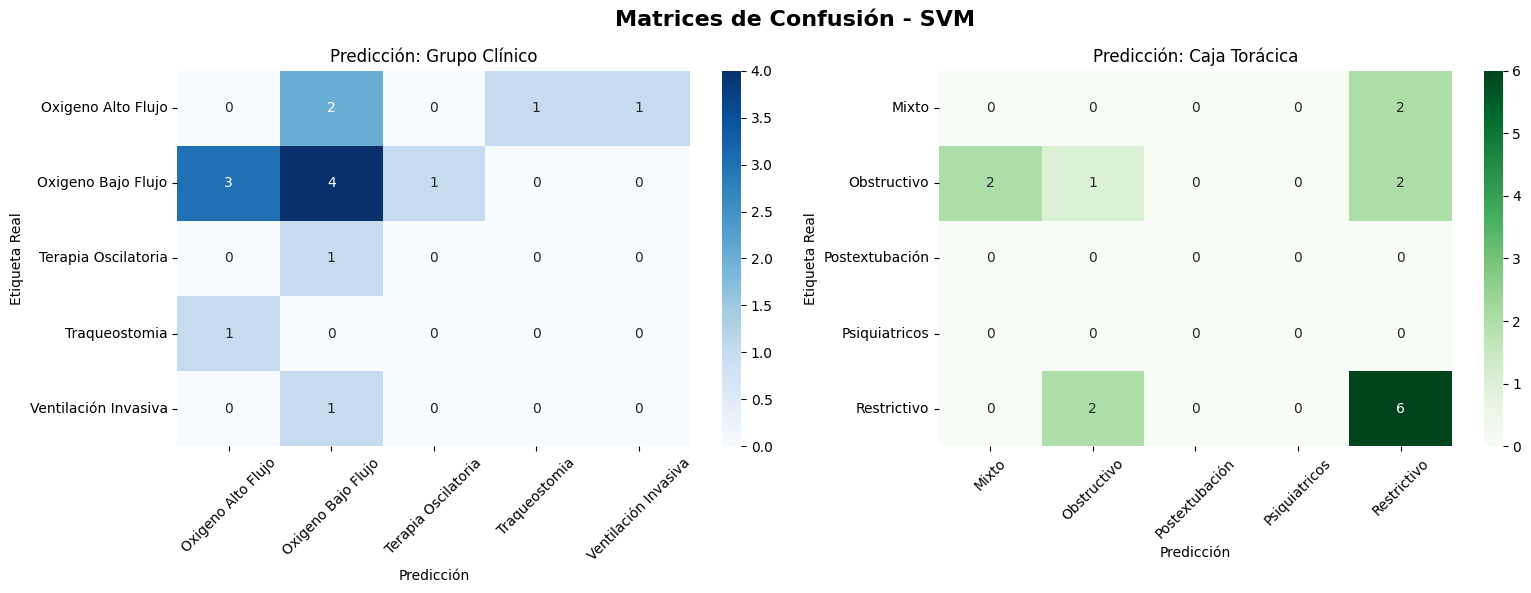

In [50]:
param_grid_svm_1 = {
    'C': [0.5, 1, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_model, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_svm_grupo, grid_svm_caja, "SVM")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 26.67% | F1-Score (Macro): 10.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 30.56%


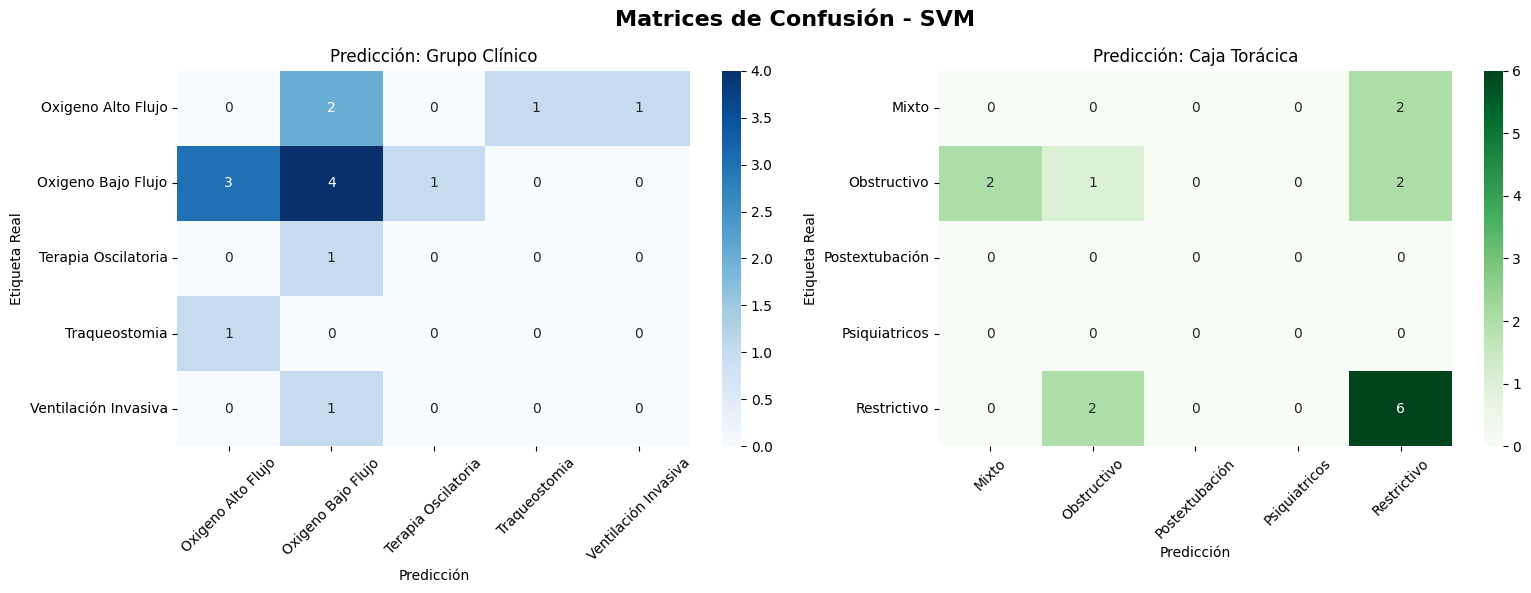

In [52]:
param_grid_svm_2_caja = {
    'C': [1.5, 2],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_2_grupo = {
    'C': [1],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_grupo, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_model, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_caja, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_model, y_train_caja)

evaluar_modelo(grid_svm_grupo, grid_svm_caja, "SVM")

Observamos que el rendimiento no mejora.

#### Gradient Boosting

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 40.00% | F1-Score (Macro): 17.78%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 29.67%


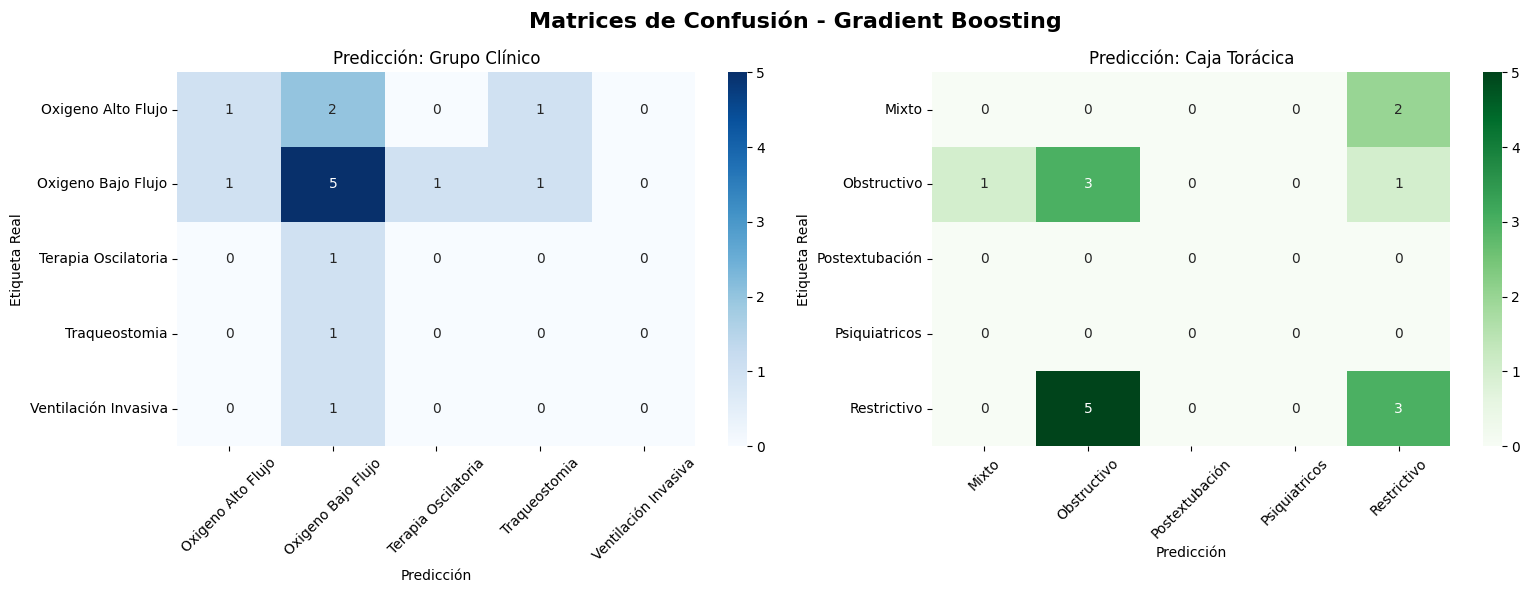

In [54]:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
param_grid_gb = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [2]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 50}
GRUPOS -> Accuracy: 33.33% | F1-Score (Macro): 30.00%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 29.67%


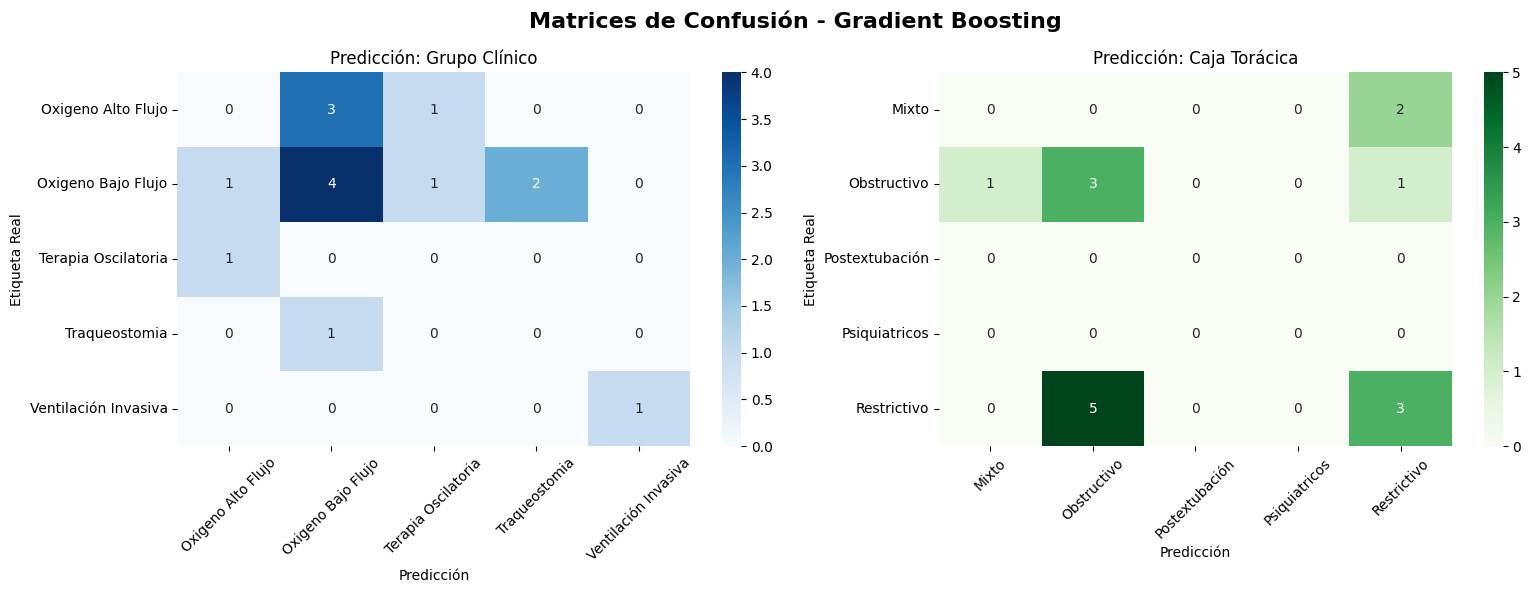

In [57]:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
param_grid_gb_1 = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [1,3],
    'min_samples_split': [2, 3]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 6, 'n_estimators': 50}
GRUPOS -> Accuracy: 33.33% | F1-Score (Macro): 30.00%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 39.83%


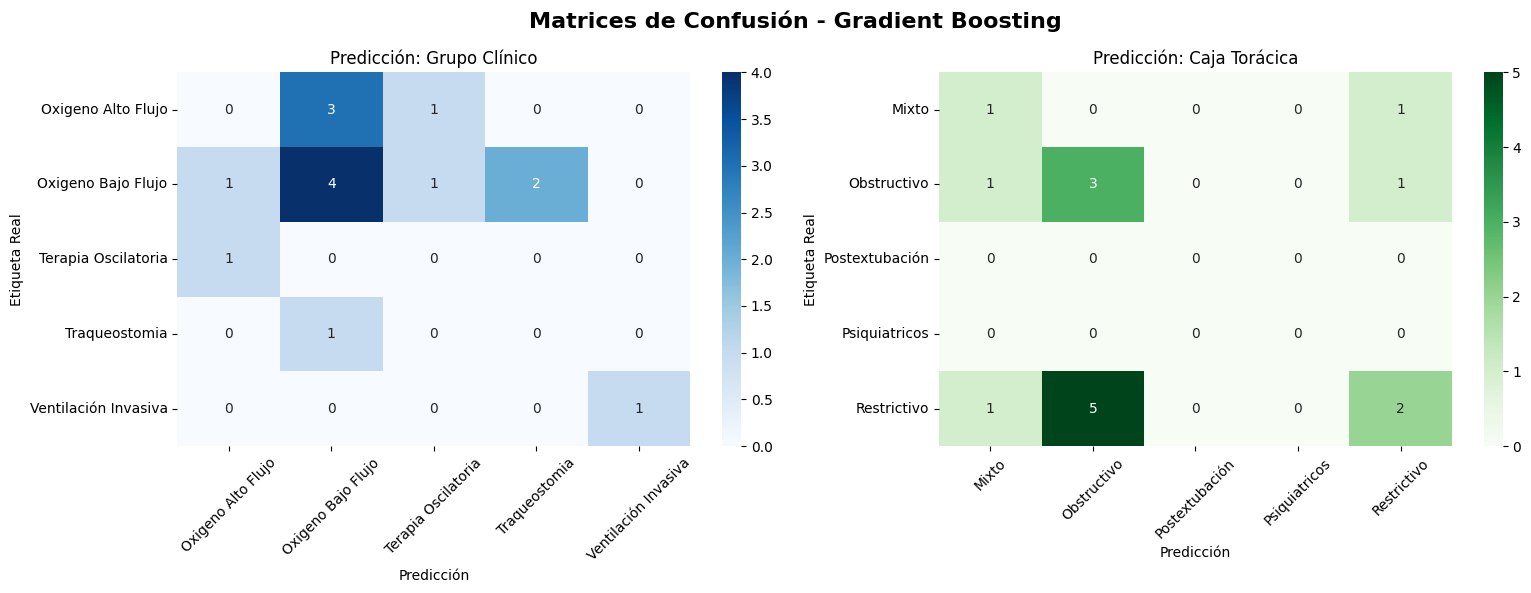

In [59]:
param_grid_gb_2_grupo = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.2],
    'max_depth': [1],
    'min_samples_split': [2, 6]
}

param_grid_gb_2_caja = {
    'n_estimators': [50],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 6],
    'min_samples_split': [3, 6]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_2_grupo, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_2_caja, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 8, 'min_samples_split': 6, 'n_estimators': 200}
GRUPOS -> Accuracy: 33.33% | F1-Score (Macro): 30.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 34.44%


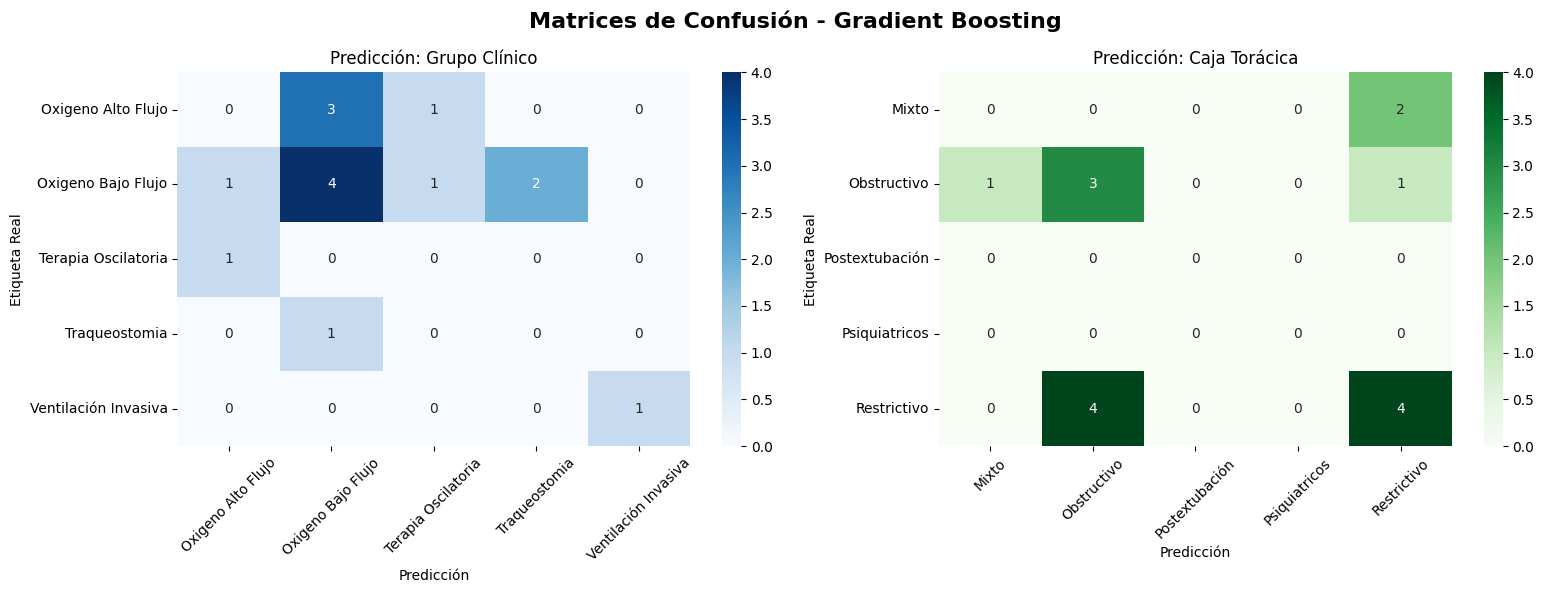

In [61]:
param_grid_gb_final_grupo = {
    'n_estimators': [100],
    'learning_rate': [0.05],
    'max_depth': [1],
    'min_samples_split': [2]
}

param_grid_gb_2_caja = {
    'n_estimators': [50, 200],
    'learning_rate': [0.1],
    'max_depth': [6, 8],
    'min_samples_split': [6, 8]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_2_grupo, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_2_caja, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Con esto podemos observar, que pese a que el rendimiento pueda ir aumentando, llega un momento en el que no mejora del todo. Como ya hemos alcanzado la mejor posible combinación de hiperparámetros para Gradient Boosting. En general podemos concluir que utilizar Embedding de Wav2Vec2 con un preprocesamiento básico, sin chunking y con pooling, es un "error". No podemos establecer que sea un fracaso, ya que como hemos dicho, nuestro objetivo es buscar alternativas y probar, sin embargo, para esta alternativa específica, los resultados han sido mediocres, incluso podemos decir que malos. Por ello, buscaremos otros métodos que puedan funcionar mejor.

### Ruta 2

Nosotros, para hacer la selección supervisada de características usando de la técnica SelectKBest, tenemos diversas opciones:
    
    1- Creamos una clase combinada entre los dos valores objetivo (grupo y caja toracica): esto se debe a que SelectKBest solo permite seleccionar las mejores características para una sola clase objetivo.
    2- Seleccionamos las mejores características para grupo y las mejores características para caja toracica: esto nos llevaría a tener dos datasets distintos, uno para cada clase a predecir.

En nuestro caso, solo podemos aplicar la estrategia 2. Esto se debe al modo de preparación de los datos que hemos seleccionado: la validación estratificada. Si nosotros creamos una clase combinada después de hacer la partición de datos siguiendo la crosvalidación estratificada, con la que buscamos en todo momento que el Nº de datos por cada clase sea el mismo, entonces estaríamos rompiendo la proporción.

In [68]:
#Separamos valores a usar en la predicción de las otras columnas:
X_train_num = df_train_reducido.drop(columns=columnas_a_quitar)
X_test_num = df_test_reducido.drop(columns=columnas_a_quitar)

#Escalamos valores
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

#Obtenemos metadatos
meta_train = df_train_reducido[columnas_a_quitar].reset_index(drop=True)
meta_test = df_test_reducido[columnas_a_quitar].reset_index(drop=True)

In [74]:
y_train_grupo = meta_train['grupo']
y_test_grupo = meta_test['grupo']

y_train_caja = meta_train['caja_toracica']
y_test_caja = meta_test['caja_toracica']

K_FEATURES = 15 #Seleccionamos las 15 mejores características.

#Seleccionamos tener 15 características, ya que si buscamos un número mayor, entonces nos encontraremos ante un posible caso de sobreentrenamiento, con un dataset de una baja cantidad de
#datos, con un gran número de características para entrenar modelos.

#Seleccionamos para grupo
selector_grupo = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_grupo_selected = selector_grupo.fit_transform(X_train_scaled, y_train_grupo)
X_test_grupo_selected = selector_grupo.transform(X_test_scaled)

#Seleccionamos para caja
selector_caja = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_caja_selected = selector_caja.fit_transform(X_train_scaled, y_train_caja)
X_test_caja_selected = selector_caja.transform(X_test_scaled)

#### Entrenamiento de modelos

Ahora podemos pasar directamente a hacer el entrenamiento de modelos, pero usando los conjuntos de datos "selected"

##### RF

In [78]:
def evaluar_modelo_kbest(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros para Grupo Clínico: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros para Torácica: {grid_caja.best_params_}")
    
    pred_grupo = grid_grupo.predict(X_test_grupo)
    pred_caja = grid_caja.predict(X_test_caja)
    
    # Evaluación GRUPOS
    acc_grupo = accuracy_score(y_test_grupo, pred_grupo)
    f1_grupo = f1_score(y_test_grupo, pred_grupo, average='macro', zero_division=0)
    print(f"GRUPOS -> Accuracy: {acc_grupo*100:.2f}% | F1-Score (Macro): {f1_grupo*100:.2f}%")
    
    # Evaluación CAJA TORÁCICA
    acc_caja = accuracy_score(y_test_caja, pred_caja)
    f1_caja = f1_score(y_test_caja, pred_caja, average='macro', zero_division=0)
    print(f"CAJA TORÁCICA -> Accuracy: {acc_caja*100:.2f}% | F1-Score (Macro): {f1_caja*100:.2f}%")
    
    # Matrices de Confusión
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold')
    
    cm_grupo = confusion_matrix(y_test_grupo, pred_grupo, labels=grid_grupo.classes_)
    sns.heatmap(cm_grupo, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=grid_grupo.classes_, yticklabels=grid_grupo.classes_)
    axes[0].set_title('Predicción: Grupo Clínico')
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)
    
    cm_caja = confusion_matrix(y_test_caja, pred_caja, labels=grid_caja.classes_)
    sns.heatmap(cm_caja, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=grid_caja.classes_, yticklabels=grid_caja.classes_)
    axes[1].set_title('Predicción: Caja Torácica')
    axes[1].set_ylabel('Etiqueta Real')
    axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 53.33% | F1-Score (Macro): 27.33%
CAJA TORÁCICA -> Accuracy: 53.33% | F1-Score (Macro): 37.04%


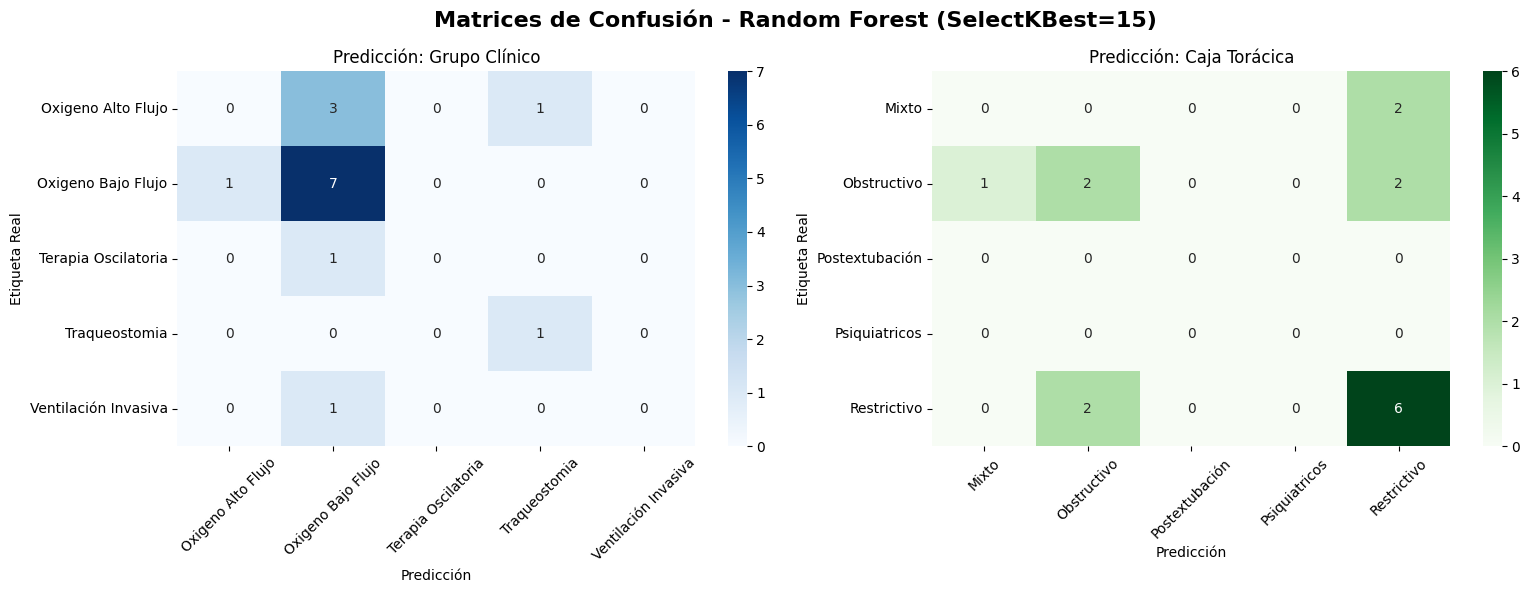

In [82]:
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
GRUPOS -> Accuracy: 53.33% | F1-Score (Macro): 20.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 29.39%


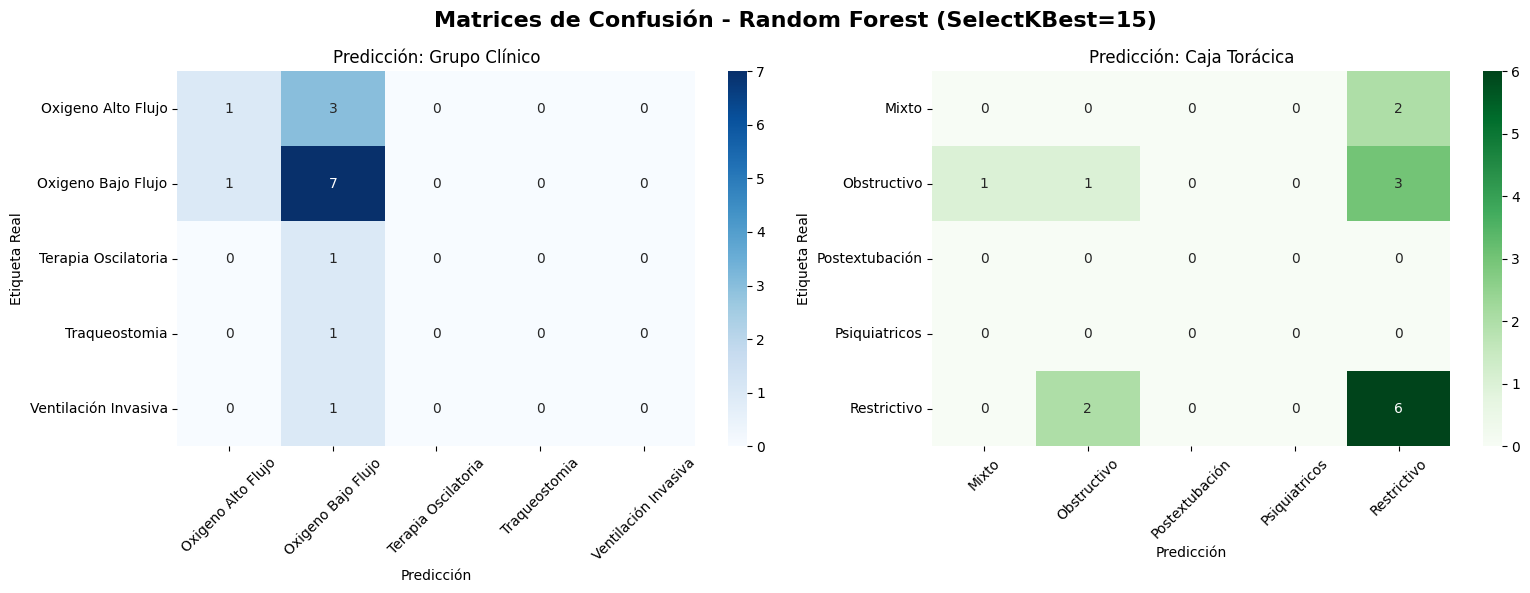

In [88]:
param_grid_rf_1 = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 40.00% | F1-Score (Macro): 12.00%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 24.02%


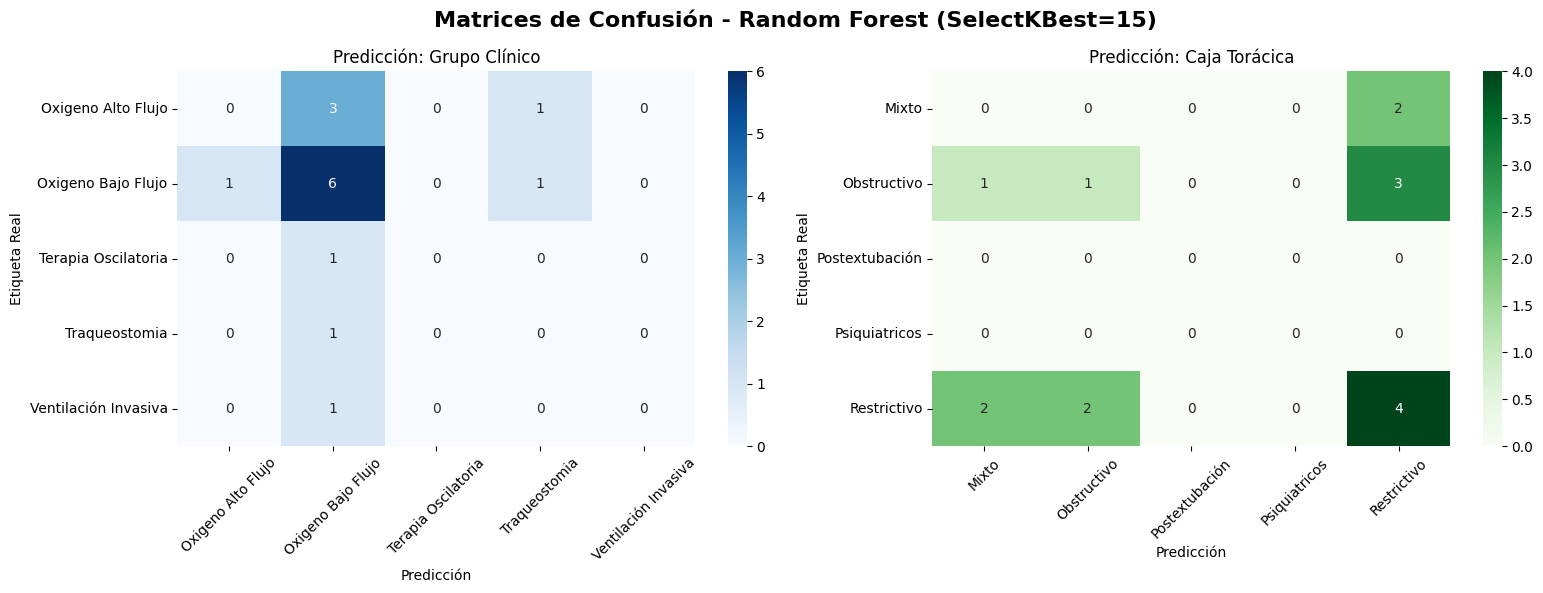

In [92]:
param_grid_rf_2 = {
    'n_estimators': [100],      
    'max_depth': [None, 5],        
    'min_samples_split': [5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
GRUPOS -> Accuracy: 53.33% | F1-Score (Macro): 20.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 29.39%


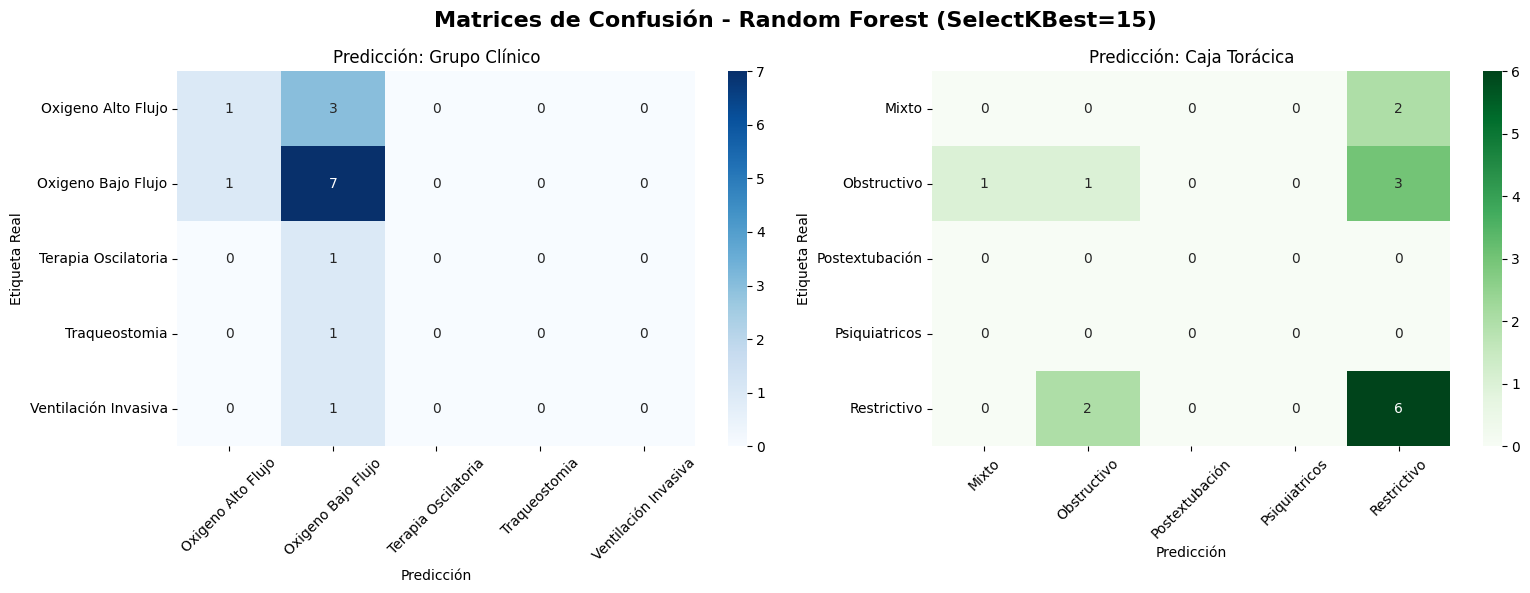

In [94]:
param_grid_rf_3 = {
    'n_estimators': [200],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 40.00% | F1-Score (Macro): 12.00%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 24.02%


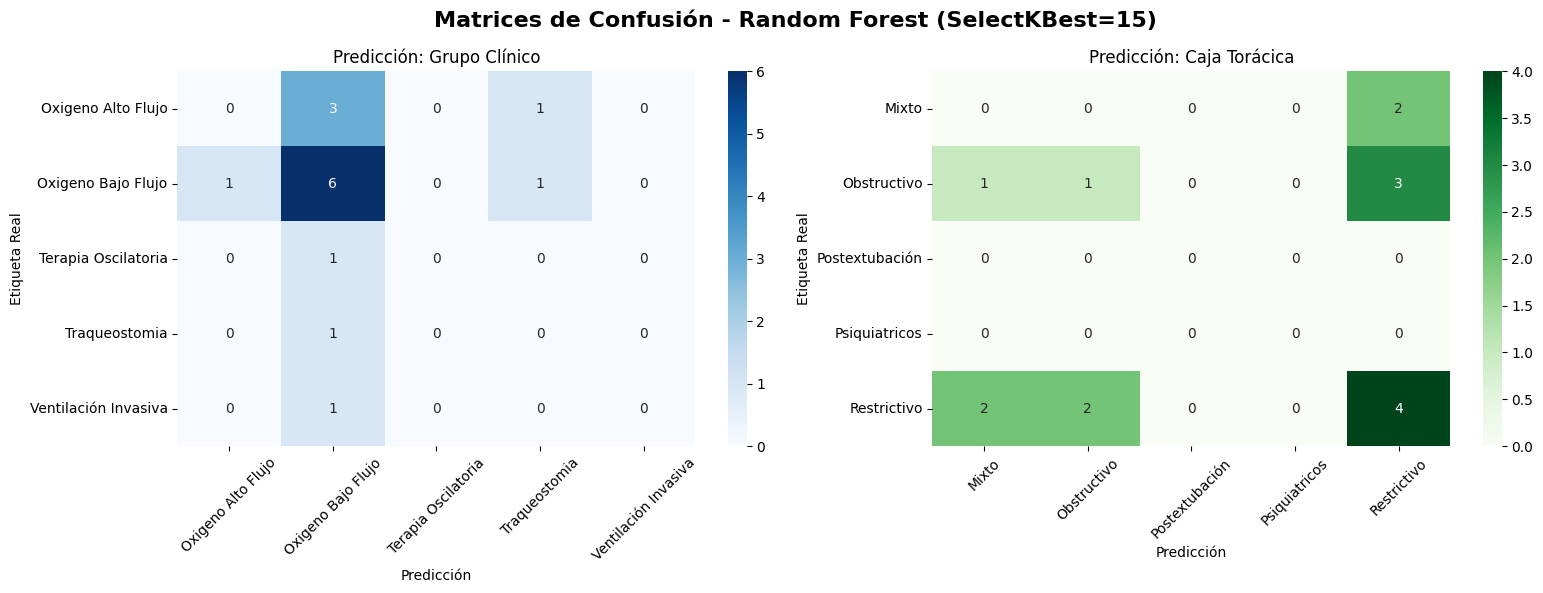

In [96]:
param_grid_rf_1 = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)

rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_rf_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest(
    grid_grupo=grid_rf_grupo, 
    grid_caja=grid_rf_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Random Forest (SelectKBest=15)"
)

Podemos observar que en este caso, la mejor configuración es la básica.

##### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 60.00% | F1-Score (Macro): 40.67%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 24.44%


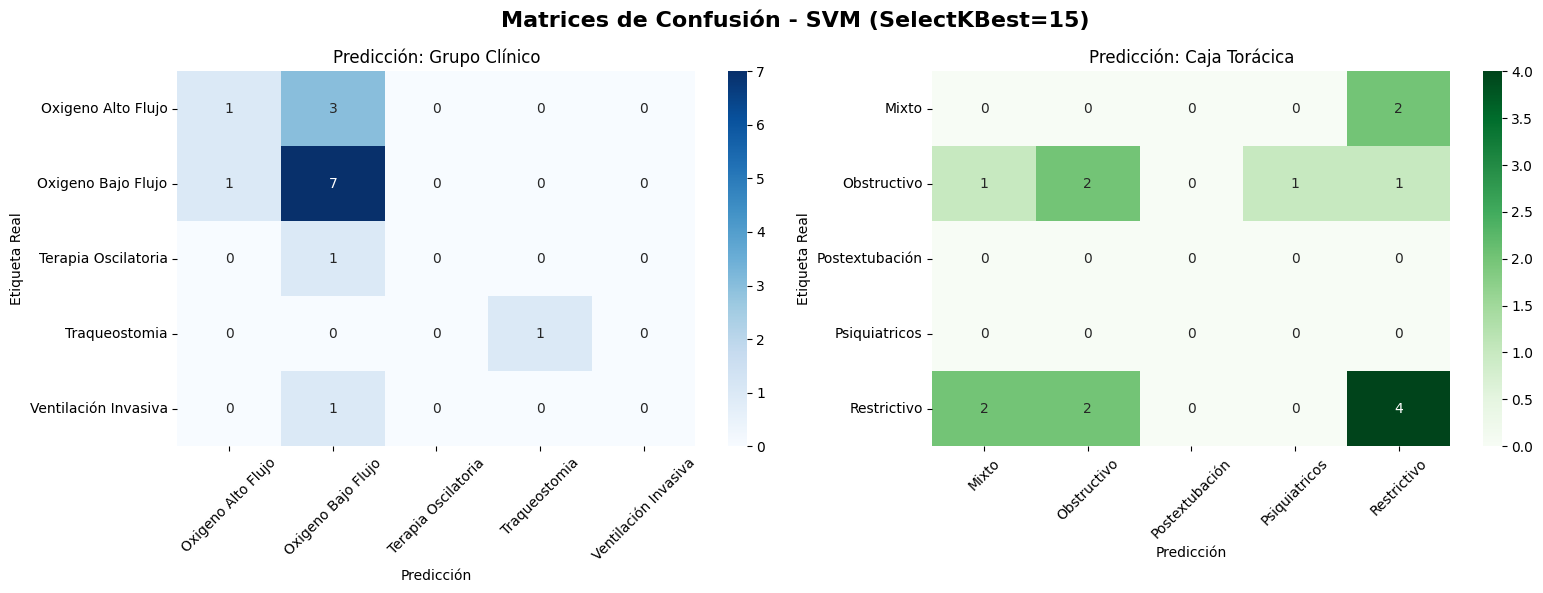

In [102]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 60.00% | F1-Score (Macro): 40.67%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 24.44%


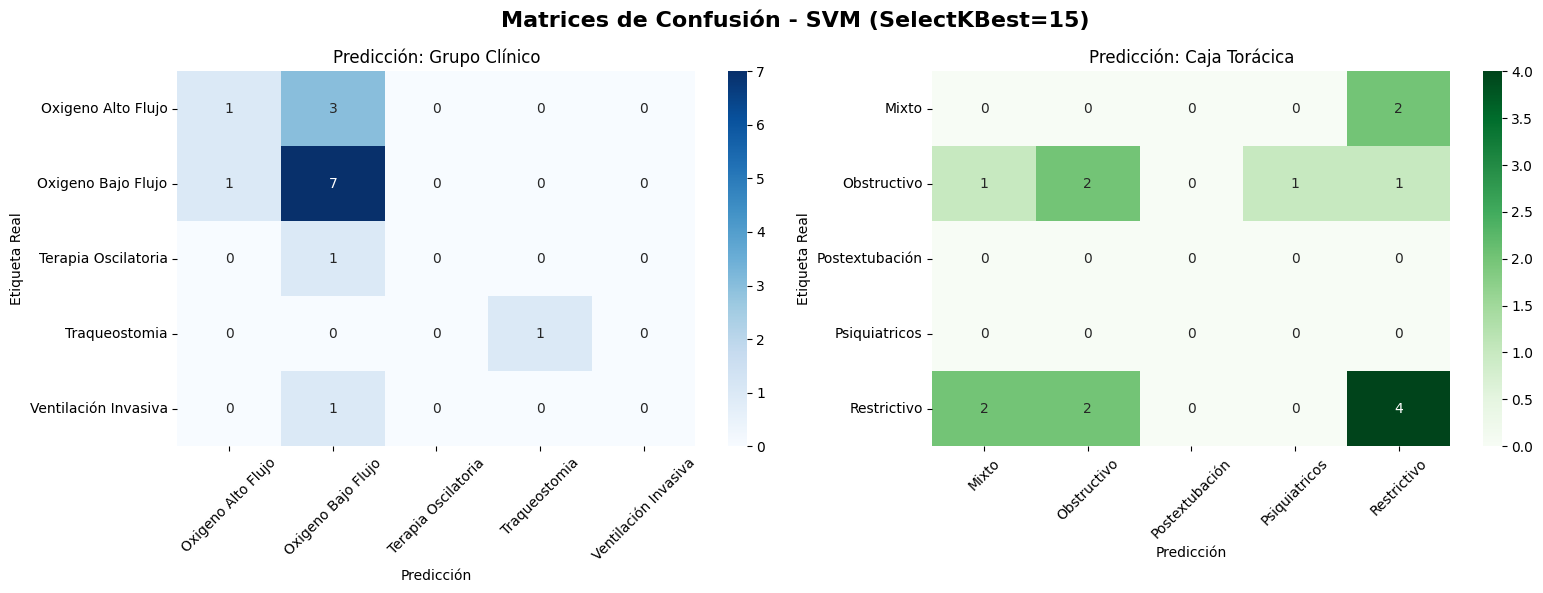

In [106]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svm_base_grupo = SVC(class_weight='balanced', random_state=42)
grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)

svm_base_caja = SVC(class_weight='balanced', random_state=42)
grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_svm_caja.fit(X_train_caja_selected, y_train_caja)

evaluar_modelo_kbest(
    grid_grupo=grid_svm_grupo, 
    grid_caja=grid_svm_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="SVM (SelectKBest=15)"
)

Observamos que el rendimiento no mejora, sin embargo, hemos obtenido un rendimiento decente para la predicción de grupos.

##### Gradient Boosting

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 46.67% | F1-Score (Macro): 22.12%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 25.88%


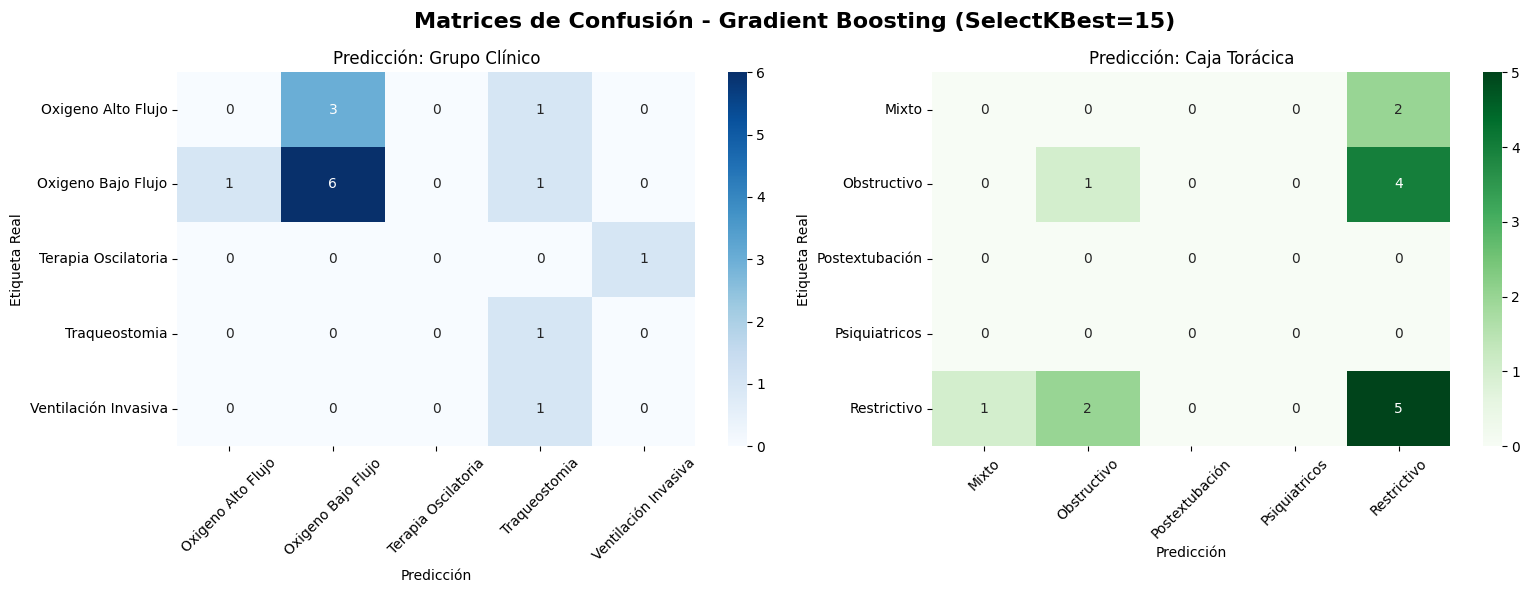

In [112]:
param_grid_gb = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [2]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_grupo_selected, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_caja_selected, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo_kbest(
    grid_grupo=grid_gb_grupo, 
    grid_caja=grid_gb_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Gradient Boosting (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 50}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
GRUPOS -> Accuracy: 40.00% | F1-Score (Macro): 13.33%
CAJA TORÁCICA -> Accuracy: 33.33% | F1-Score (Macro): 23.15%


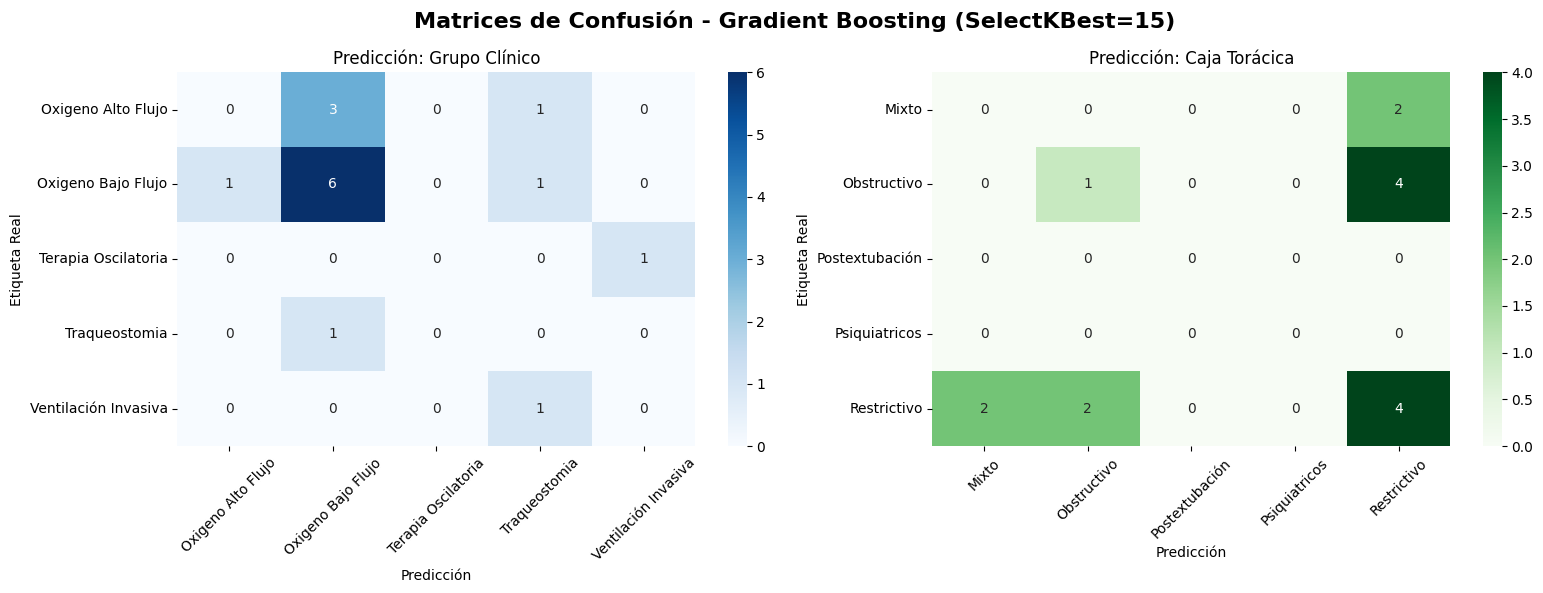

In [115]:
param_grid_gb_1 = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [1,3],
    'min_samples_split': [2, 3]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_grupo_selected, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_1, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_caja_selected, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo_kbest(
    grid_grupo=grid_gb_grupo, 
    grid_caja=grid_gb_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Gradient Boosting (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 100}
GRUPOS -> Accuracy: 26.67% | F1-Score (Macro): 10.00%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 25.88%


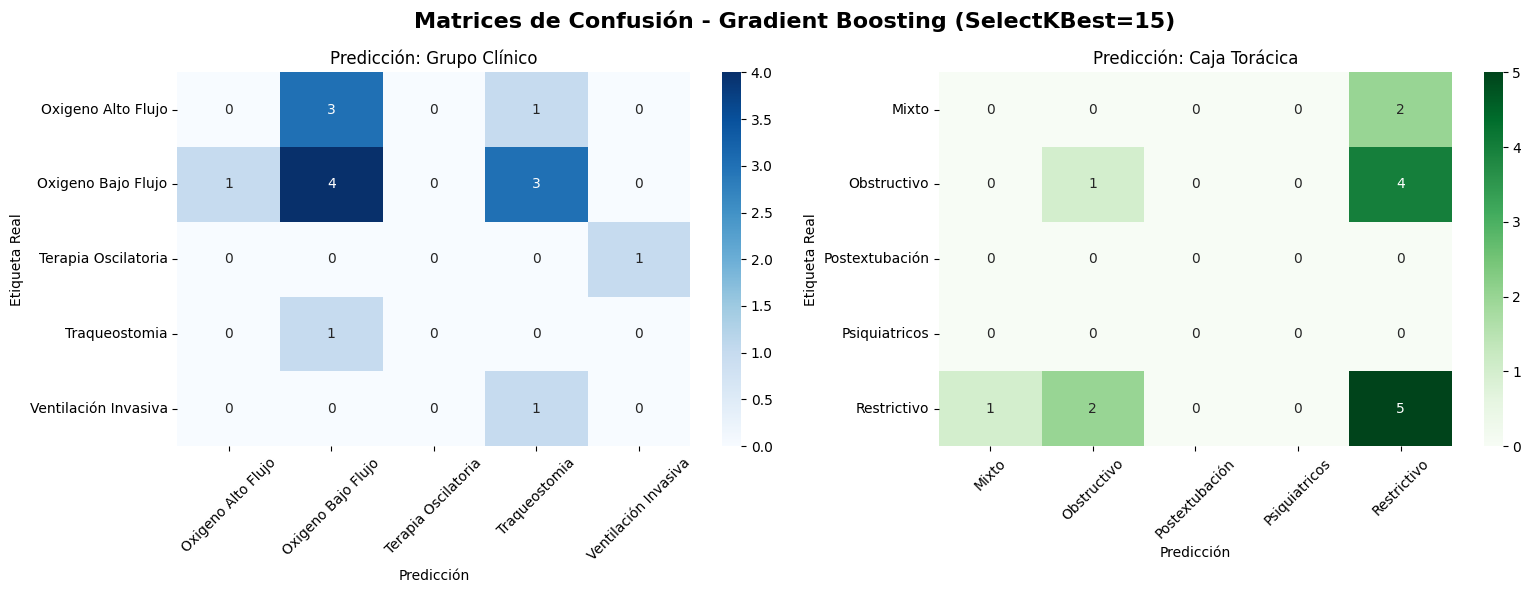

In [117]:
param_grid_gb_2 = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3],
    'min_samples_split': [3]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_grupo_selected, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_2, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_caja_selected, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo_kbest(
    grid_grupo=grid_gb_grupo, 
    grid_caja=grid_gb_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Gradient Boosting (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 200}
GRUPOS -> Accuracy: 46.67% | F1-Score (Macro): 22.12%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 25.88%


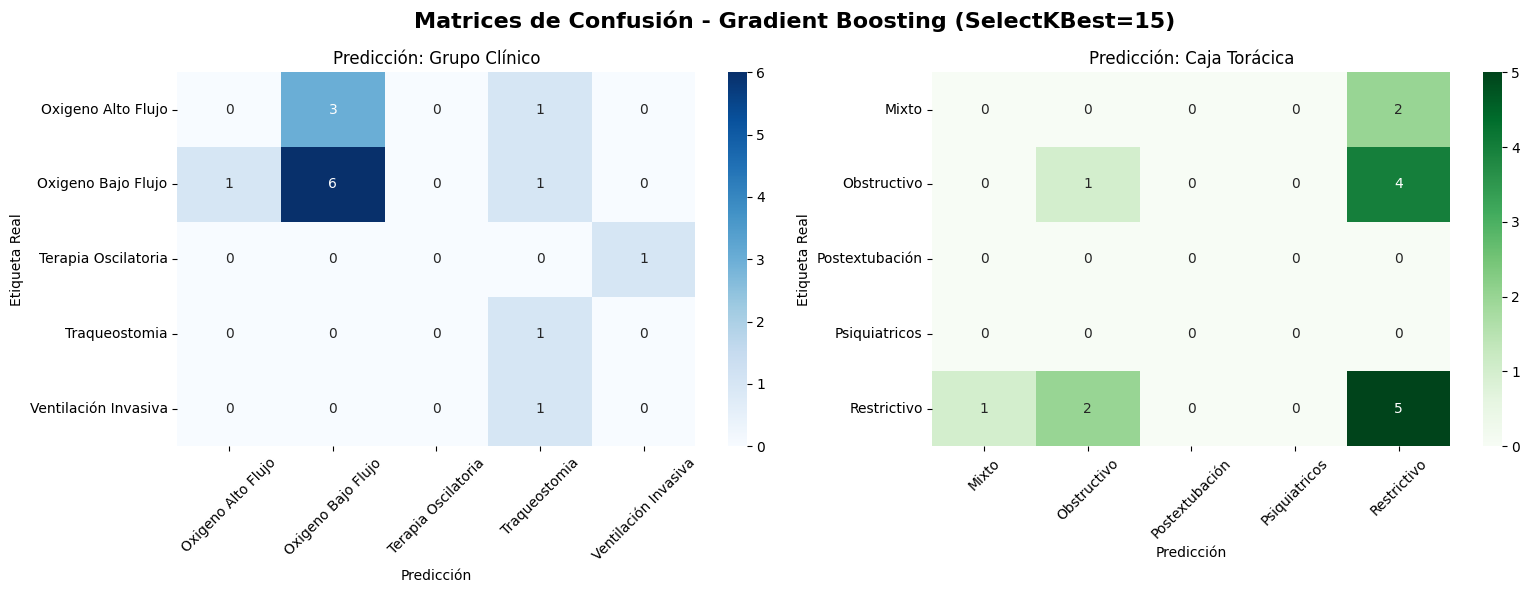

In [119]:
param_grid_gb_3 = {
    'n_estimators': [200],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [3]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_3, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_grupo_selected, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_3, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_caja_selected, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo_kbest(
    grid_grupo=grid_gb_grupo, 
    grid_caja=grid_gb_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Gradient Boosting (SelectKBest=15)"
)

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.15, 'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 100}
GRUPOS -> Accuracy: 26.67% | F1-Score (Macro): 10.00%
CAJA TORÁCICA -> Accuracy: 46.67% | F1-Score (Macro): 29.52%


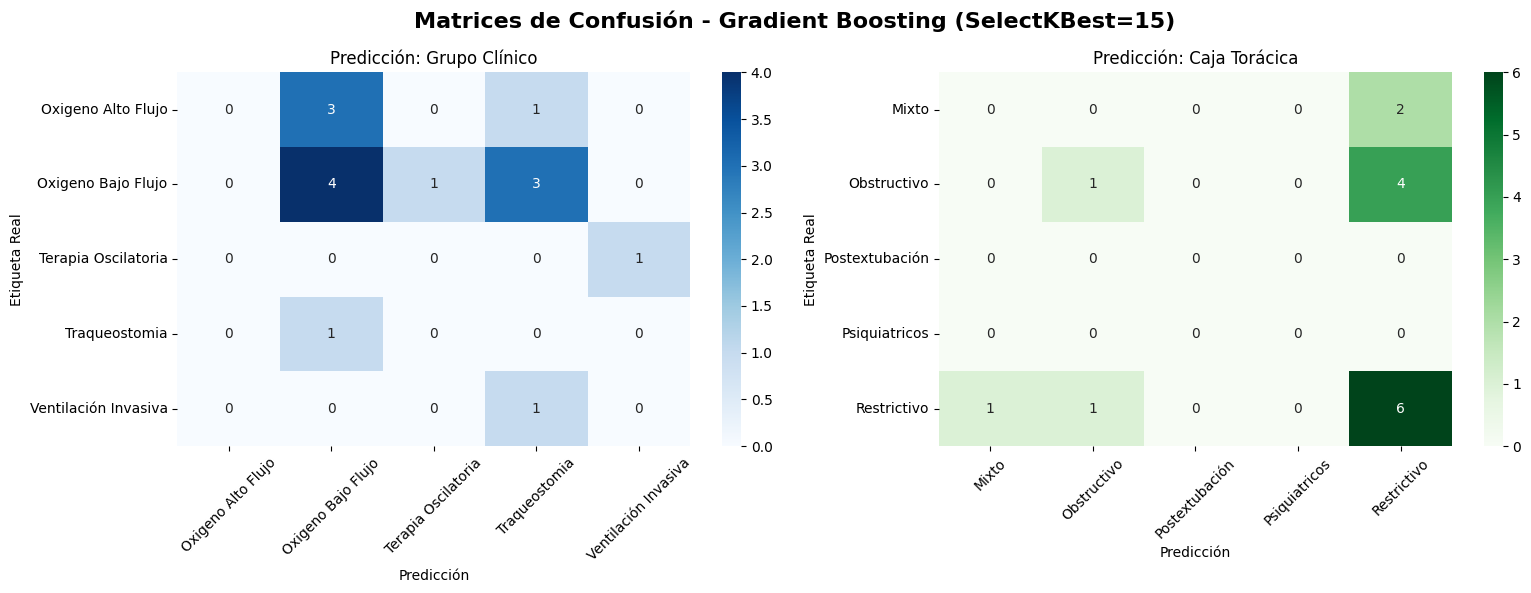

In [121]:
param_grid_gb_4 = {
    'n_estimators': [100],
    'learning_rate': [0.15],
    'max_depth': [5],
    'min_samples_split': [6]
}

pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)

gb_base_grupo = GradientBoostingClassifier(random_state=42)
grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_4, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_grupo.fit(X_train_grupo_selected, y_train_grupo, **{'sample_weight': pesos_grupo})

gb_base_caja = GradientBoostingClassifier(random_state=42)
grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_4, scoring='f1_macro', cv=ps, n_jobs=-1)
grid_gb_caja.fit(X_train_caja_selected, y_train_caja, **{'sample_weight': pesos_caja})

evaluar_modelo_kbest(
    grid_grupo=grid_gb_grupo, 
    grid_caja=grid_gb_caja, 
    X_test_grupo=X_test_grupo_selected,
    X_test_caja=X_test_caja_selected,   
    nombre_modelo="Gradient Boosting (SelectKBest=15)"
)

Como podemos observar, con Gradient Boosting tampoco podemos obtener un mejor rendimiento que con los valores determinados.